# Data Analyst Portfolio: Global COVID-19 Pandemic Analysis
Proyek ini menginvestigasi dampak penyebaran pandemi COVID-19 di seluruh dunia menggunakan sekumpulan dataset komprehensif, mulai dari tren harian global hingga penyebaran spesifik di daerah (county) Amerika Serikat.

## Pertanyaan Analisis:
1. Bagaimana tren perkembangan pandemi secara global berdasarkan jumlah kasus dan tingkat kematian dari waktu ke waktu?
2. Negara mana saja yang memiliki rasio penanganan terbaik dan terburuk?
3. Adakah korelasi antara masifnya pengujian (testing) terhadap jumlah kasus yang terkonfirmasi?
4. Bagaimana pola spesifik pusat episentrum di negara yang paling terdampak (Amerika Serikat)?


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Data Cleaning & Preprocessing

In [3]:
# Memuat Data Utama
df_day_wise = pd.read_csv('dataset/day_wise.csv')
df_world = pd.read_csv('dataset/worldometer_data.csv')
df_grouped = pd.read_csv('dataset/full_grouped.csv')
df_usa = pd.read_csv('dataset/usa_county_wise.csv')

# Menampilkan informasi sekilas
print("Day Wise Data:", df_day_wise.shape)
print("Worldometer Data:", df_world.shape)
print("Full Grouped Data (Country Time-Series):", df_grouped.shape)
print("USA County Wise:", df_usa.shape)


Day Wise Data: (188, 12)
Worldometer Data: (209, 16)
Full Grouped Data (Country Time-Series): (35156, 10)
USA County Wise: (627920, 14)


In [4]:
# Preprocessing Tanggal
df_day_wise['Date'] = pd.to_datetime(df_day_wise['Date'])
df_grouped['Date'] = pd.to_datetime(df_grouped['Date'])

# Membersihkan missing values pada data Worldometer untuk analisis komparatif
numeric_cols = df_world.select_dtypes(include=[np.number]).columns
df_world[numeric_cols] = df_world[numeric_cols].fillna(0)


## 2. Exploratory Data Analysis (EDA)
### 2.1 Analisis Tren Pandemi Global

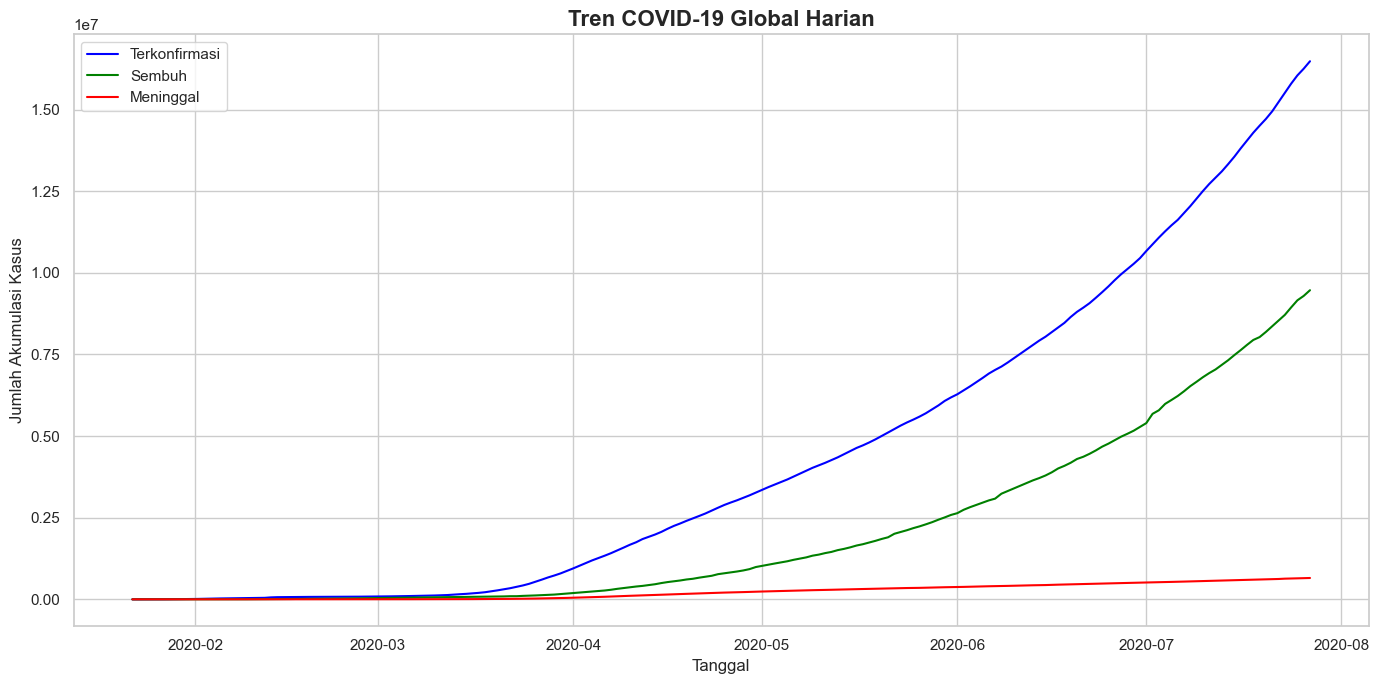

In [5]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_day_wise, x='Date', y='Confirmed', label='Terkonfirmasi', color='blue')
sns.lineplot(data=df_day_wise, x='Date', y='Recovered', label='Sembuh', color='green')
sns.lineplot(data=df_day_wise, x='Date', y='Deaths', label='Meninggal', color='red')

plt.title('Tren COVID-19 Global Harian', fontsize=16, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Jumlah Akumulasi Kasus', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


**Insight Utama Tren Global:**
* *(Silakan tambahkan insight mengenai lonjakan awal kasus dan perbandingan antara kurva sembuh vs yang meninggal).*


### 2.2 Profil Detail Negara (Top 10 Negara Kasus Terbanyak)

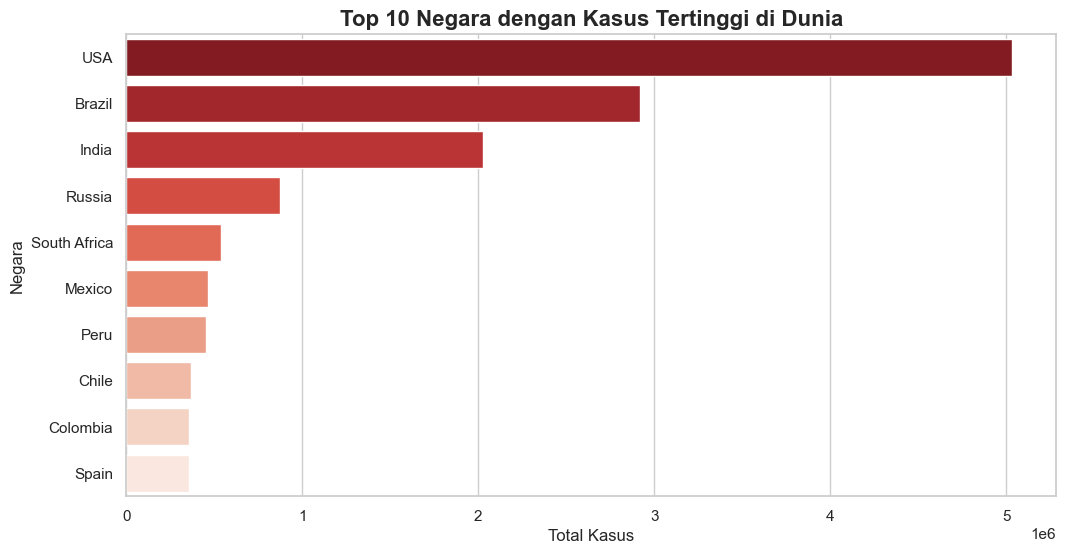

In [6]:
top_10_countries = df_world.sort_values('TotalCases', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_countries, x='TotalCases', y='Country/Region', palette='Reds_r')
plt.title('Top 10 Negara dengan Kasus Tertinggi di Dunia', fontsize=16, fontweight='bold')
plt.xlabel('Total Kasus', fontsize=12)
plt.ylabel('Negara', fontsize=12)
plt.show()


### 2.3 Papan Peringkat Penanganan (Evaluasi Rasio Kesembuhan)

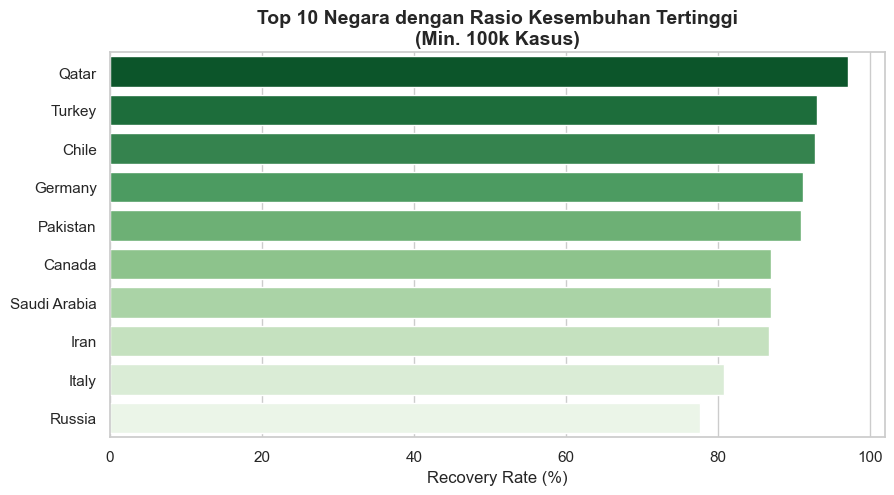

In [7]:
# Filter negara dengan minimal 100.000 kasus agar lebih objektif
df_eval = df_world[df_world['TotalCases'] > 100000].copy()

# Membuat metrik Rasio Kesembuhan (Recovery Rate)
df_eval['Recovery_Rate_Pct'] = (df_eval['TotalRecovered'] / df_eval['TotalCases']) * 100

top_recovered = df_eval.sort_values('Recovery_Rate_Pct', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_recovered, x='Recovery_Rate_Pct', y='Country/Region', palette='Greens_r')
plt.title('Top 10 Negara dengan Rasio Kesembuhan Tertinggi\n(Min. 100k Kasus)', fontsize=14, fontweight='bold')
plt.xlabel('Recovery Rate (%)', fontsize=12)
plt.ylabel('')
plt.show()


### 2.4 Korelasi Pengujian terhadap Angka Konfirmasi Kasus

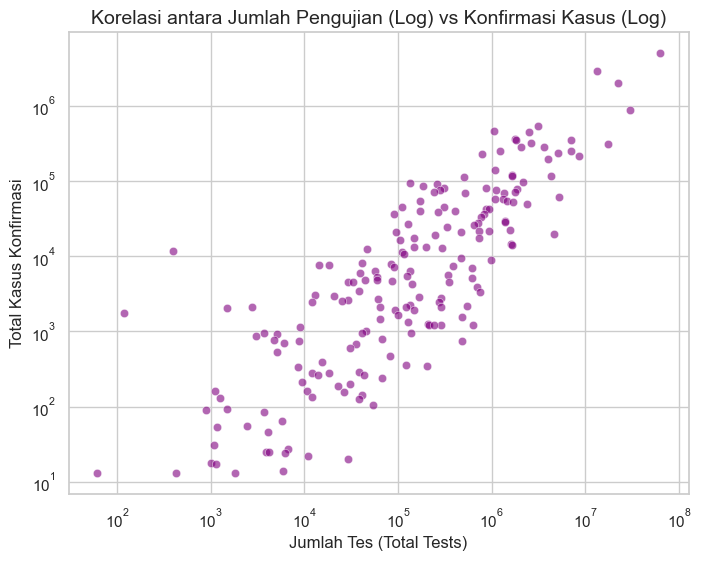

In [14]:
plt.figure(figsize=(8, 6))

# Pisahkan filternya ke sini
df_world_clean = df_world[df_world['TotalTests'] > 0]

# Panggil variabelnya di dalam plot
sns.scatterplot(data=df_world_clean, x='TotalTests', y='TotalCases', alpha=0.6, color='purple')

plt.xscale('log')
plt.yscale('log')
plt.title('Korelasi antara Jumlah Pengujian (Log) vs Konfirmasi Kasus (Log)', fontsize=14)
plt.xlabel('Jumlah Tes (Total Tests)')
plt.ylabel('Total Kasus Konfirmasi')
plt.show()

### 2.5 Pelacakan Episentrum Amerika Serikat

In [13]:
# Menemukan wilayah/state mana di USA yang memiliki akumulasi kasus terbesar di tanggal akhir observasi
if not df_usa.empty:
    kondisi_tanggal_terakhir = df_usa['Date'] == df_usa['Date'].max()
    usa_latest = df_usa[kondisi_tanggal_terakhir]
    state_cases = usa_latest.groupby('Province_State')['Confirmed'].sum().sort_values(ascending=False).head(5)
    
    print("Top 5 Negara Bagian (State) Paling Terdampak di Amerika Serikat:")
    print(state_cases)


Top 5 Negara Bagian (State) Paling Terdampak di Amerika Serikat:
Province_State
New York      399513
California    302484
Texas         236541
Florida       232718
New Jersey    174270
Name: Confirmed, dtype: int64


## 3. Kesimpulan Eksekutif (Executive Summary)

Berdasarkan eksplorasi dataset COVID-19 skala global pada periode paruh pertama 2020 (Januari - Juli), dapat ditarik beberapa temuan analitik kunci:

1. **Tren Eskalasi Konstan**: Secara agregat global, kurva jumlah terkonfirmasi (*Confirmed Cases*) terus mengalami lonjakan eksponensial mulai bulan Maret tanpa adanya indikasi fase melandai secara komprehensif. Titik terang terlihat pada garis angka kesembuhan (*Recovered*) yang perlahan terus membuntuti angka kasus secara konsisten.
2. **Dominasi Tiga Negara Utama**: Amerika Serikat (USA), Brazil, dan India menduduki puncak klasemen absolut terbesar di dunia untuk jumlah penularan dan korban jiwa pada masa observasi. Khusus untuk USA, episentrum penyebaran paling masif pada level teritorial (*state*) dipimpin kuat oleh pesisir dan wilayah sentral ekonomi (misalnya: New York, California, dan Florida).
3. **Korelasi Positif Pengujian (Testing)**: Visualisasi *Scatter Plot* mengonfirmasi sifat korelasi logaritmik yang positif dan nyata antara masifnya jumlah pengetesan sampel oleh pemerintah dengan naiknya angka kasus yang bisa diidentifikasi. Artinya, jumlah kasus harian yang rendah di beberapa negara kemungkinan merepresentasikan rendahnya fasilitas uji (*Testing Capability*), bukan berarti mereka lebih aman.
4. **Disrupsi Regional**: Rasio kesembuhan (Recovery Rate) sangat fluktuatif berdasarkan regional per kapita. Negara maju belum tentu mencetak rasio kesembuhan terbaik jika kurva infeksinya melampaui kemampuan daya tampung tenaga rumah sakit (Kolaps Fasilitas Kesehatan).

*Portofolio ini secara sukses mentransformasikan jutaan baris data tabular kasar menjadi dasbor interaktiv terpadu dan narasi bisnis yang komprehensif.*
